# Machine Learning — Notebook 07  
## Árboles de decisión: clasificación, regresión y control del sobreajuste

### Objetivos
- Entender cómo un árbol de decisión **particiona el espacio de features** de forma recursiva.
- Ver cómo un árbol sin restricciones **sobreajusta** (memoriza el train).
- Controlar el sobreajuste con **`max_depth`**, **`min_samples_leaf`** y otros hiperparámetros.
- Usar árboles para **regresión** (no solo clasificación).
- Interpretar **feature importance** (basada en impureza).
- Comparar árbol (con y sin control) contra baseline y logística.

### Ideas clave
- Un árbol aprende reglas del tipo: *si `x1 < 3.2` y `x2 ≥ 0.7` → clase 1*.
- Sin límites crece hasta memorizar cada punto de train → alta varianza.
- `max_depth` y `min_samples_leaf` son los controles más intuitivos y efectivos.
- Feature importance mide cuánto reduce la impureza cada feature, promediado sobre todos los splits.
- Para regresión, el árbol predice el **promedio** del target en cada hoja.

> Trabajaremos con datos simulados 2D (para visualizar fronteras) y luego con un dataset tabular de mayor dimensión.

---
## 0) Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    roc_auc_score, average_precision_score,
    mean_squared_error, mean_absolute_error, r2_score,
    confusion_matrix
)
from sklearn.datasets import make_classification, make_regression

RANDOM_STATE = 7
rng = np.random.default_rng(RANDOM_STATE)

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 200)

---
## 1) Árbol de clasificación en 2D: intuición geométrica

Un árbol de decisión divide el espacio de features con **cortes ortogonales** (paralelos a los ejes).  
Cada corte minimiza la **impureza de Gini** (o entropía) en los dos nodos hijo:

$$
\text{Gini}(t) = 1 - \sum_{k} p_k^2
$$

donde $p_k$ es la proporción de clase $k$ en el nodo $t$.  
- Gini = 0 → nodo puro (solo una clase).  
- Gini = 0.5 → máximo desorden (50/50 en binario).

Visualizaremos cómo la frontera cambia al variar `max_depth`.

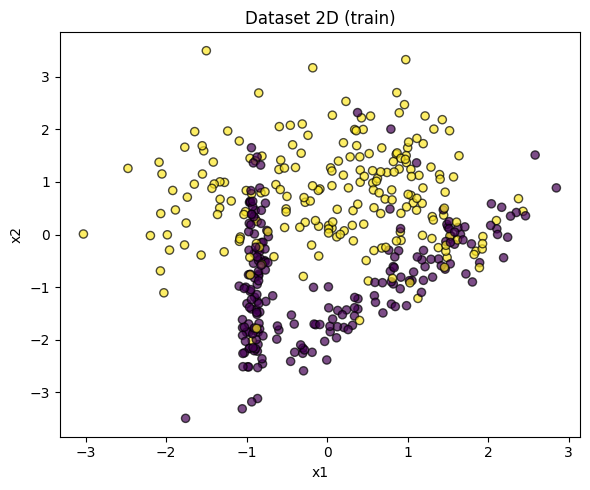

In [2]:
# 1.1 Dataset 2D simulado
X2, y2 = make_classification(
    n_samples=600,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=2,
    class_sep=0.9,
    flip_y=0.06,
    random_state=RANDOM_STATE
)

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.30, random_state=RANDOM_STATE, stratify=y2
)

plt.figure(figsize=(6, 5))
plt.scatter(X2_train[:, 0], X2_train[:, 1], c=y2_train, alpha=0.7, edgecolor="k", s=35)
plt.title("Dataset 2D (train)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.tight_layout()
plt.show()

In [3]:
def plot_decision_boundary_tree(model, X, y, title="Decision boundary", steps=300):
    """Visualiza la frontera de decisión de un clasificador 2D."""
    x1_min, x1_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    x2_min, x2_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx1, xx2 = np.meshgrid(
        np.linspace(x1_min, x1_max, steps),
        np.linspace(x2_min, x2_max, steps)
    )
    grid = np.c_[xx1.ravel(), xx2.ravel()]
    proba = model.predict_proba(grid)[:, 1].reshape(xx1.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx1, xx2, proba, levels=20, alpha=0.85)
    plt.colorbar(label="P(y=1|x)")
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", alpha=0.75, s=30)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.tight_layout()
    plt.show()

Árbol sin restricción — profundidad: 13, hojas: 67
Árbol max_depth=3    — profundidad: 3,  hojas: 7


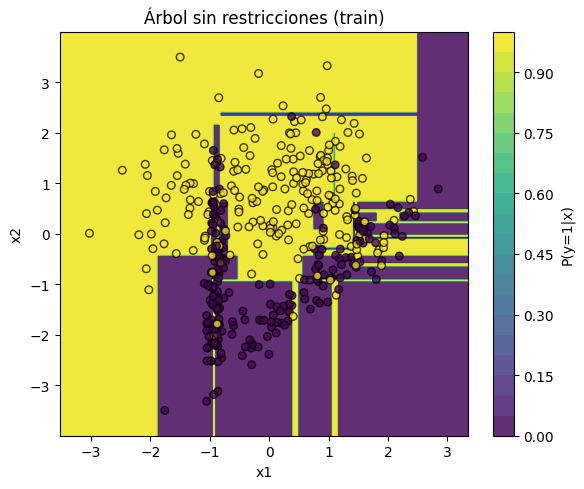

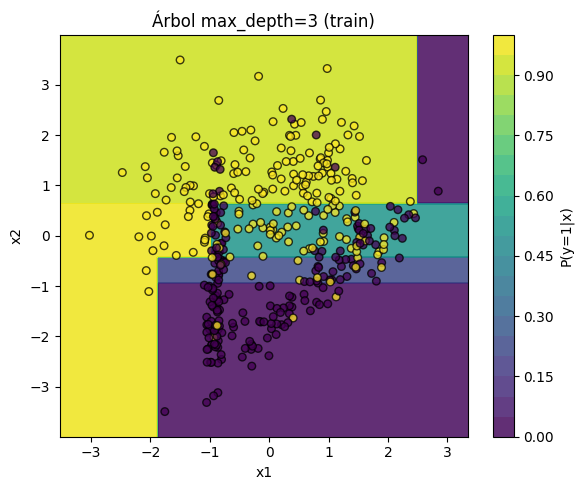

In [4]:
# 1.2 Árbol sin restricciones vs árbol con max_depth=3
dt_full = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_d3   = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)

dt_full.fit(X2_train, y2_train)
dt_d3.fit(X2_train, y2_train)

print(f"Árbol sin restricción — profundidad: {dt_full.get_depth()}, hojas: {dt_full.get_n_leaves()}")
print(f"Árbol max_depth=3    — profundidad: {dt_d3.get_depth()},  hojas: {dt_d3.get_n_leaves()}")

plot_decision_boundary_tree(dt_full, X2_train, y2_train, title="Árbol sin restricciones (train)")
plot_decision_boundary_tree(dt_d3,   X2_train, y2_train, title="Árbol max_depth=3 (train)")

---
## 2) Sobreajuste: árbol sin restricciones memoriza el train

Un árbol sin límite crece hasta que **cada hoja es pura** (o tiene un solo punto).  
Esto implica **varianza altísima**: cambia mucho ante pequeños cambios en los datos.  

La señal de alarma es una brecha grande entre accuracy de train y de test.

In [5]:
# 2.1 Comparar train vs test accuracy para diferentes max_depth
depths = list(range(1, 21))
rows = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    dt.fit(X2_train, y2_train)
    rows.append({
        "max_depth": d,
        "acc_train": accuracy_score(y2_train, dt.predict(X2_train)),
        "acc_test":  accuracy_score(y2_test,  dt.predict(X2_test)),
        "n_leaves":  dt.get_n_leaves()
    })

df_depth = pd.DataFrame(rows)
df_depth.head(10)

,max_depth,acc_train,acc_test,n_leaves
0,1,0.800000,0.744444,2
1,2,0.804762,0.744444,4
2,3,0.809524,0.755556,7
3,4,0.866667,0.800000,11
4,5,0.909524,0.850000,19
5,6,0.930952,0.794444,28
6,7,0.945238,0.788889,37
7,8,0.961905,0.800000,47
8,9,0.980952,0.783333,57
9,10,0.990476,0.777778,63


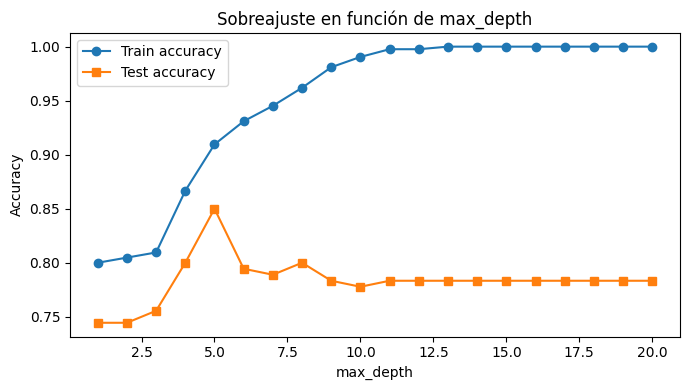

Mejor max_depth según test: 5 — Test accuracy: 0.8500


In [6]:
# 2.2 Curva de sobreajuste
plt.figure(figsize=(7, 4))
plt.plot(df_depth["max_depth"], df_depth["acc_train"], marker="o", label="Train accuracy")
plt.plot(df_depth["max_depth"], df_depth["acc_test"],  marker="s", label="Test accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Sobreajuste en función de max_depth")
plt.legend()
plt.tight_layout()
plt.show()

# Mejor test accuracy
best_row = df_depth.loc[df_depth["acc_test"].idxmax()]
print(f"Mejor max_depth según test: {int(best_row['max_depth'])} — Test accuracy: {best_row['acc_test']:.4f}")

---
## 3) Control del sobreajuste: `min_samples_leaf` y comparación conjunta

Además de `max_depth`, otro hiperparámetro muy efectivo es **`min_samples_leaf`**:  
exige que cada hoja tenga al menos $m$ muestras → evita hojas con un solo punto.

| Hiperparámetro | Efecto |
|---|---|
| `max_depth` | Limita la profundidad del árbol |
| `min_samples_leaf` | Mínimo de muestras en cada hoja |
| `min_samples_split` | Mínimo para volver a dividir un nodo |
| `max_leaf_nodes` | Número máximo de hojas |

Usaremos el **dataset tabular** de mayor dimensión (más realista) y compararemos configuraciones con **validación cruzada**.

In [7]:
# 3.1 Dataset tabular simulado (mayor dimensión)
X, y = make_classification(
    n_samples=2500,
    n_features=12,
    n_informative=6,
    n_redundant=3,
    weights=[0.70, 0.30],
    class_sep=1.0,
    flip_y=0.04,
    random_state=RANDOM_STATE
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

print("Train size:", X_train.shape)
print("Class balance (train):", pd.Series(y_train).value_counts(normalize=True).to_dict())

Train size: (1875, 12)
Class balance (train): {0: 0.6901333333333334, 1: 0.3098666666666667}


In [8]:
# 3.2 Grid: max_depth × min_samples_leaf con CV (F1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

depth_grid = [2, 3, 4, 5, 7, 10, None]
leaf_grid  = [1, 5, 10, 20, 50]
rows = []

for d in depth_grid:
    for ml in leaf_grid:
        dt = DecisionTreeClassifier(
            max_depth=d, min_samples_leaf=ml,
            random_state=RANDOM_STATE
        )
        scores = cross_val_score(dt, X_train, y_train, cv=cv, scoring="f1")
        rows.append({
            "max_depth": str(d),
            "min_samples_leaf": ml,
            "f1_mean": scores.mean(),
            "f1_std":  scores.std()
        })

df_grid = pd.DataFrame(rows).sort_values("f1_mean", ascending=False)
df_grid.head(10)

,max_depth,min_samples_leaf,f1_mean,f1_std
10,4,1,0.659666,0.038200
11,4,5,0.658571,0.037347
12,4,10,0.658259,0.040310
21,7,5,0.654609,0.043015
26,10,5,0.654546,0.026808
13,4,20,0.653022,0.039903
28,10,20,0.652958,0.044139
20,7,1,0.651681,0.033035
33,None,20,0.651651,0.044681
32,None,10,0.651601,0.032228


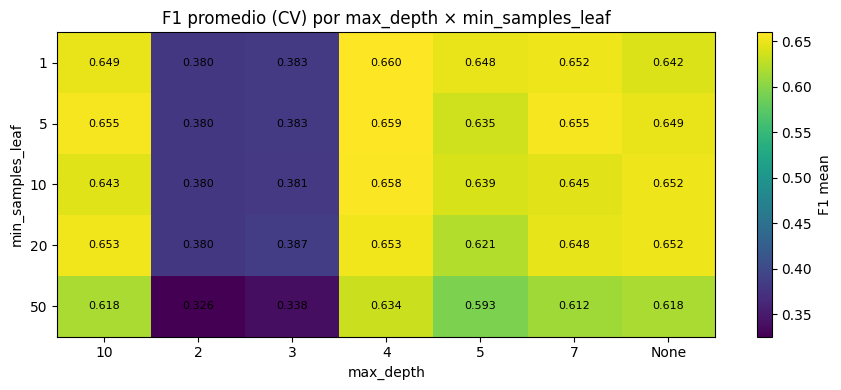

In [9]:
# 3.3 Visualizar: heatmap de F1 promedio
pivot = df_grid.pivot(index="min_samples_leaf", columns="max_depth", values="f1_mean")

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(pivot.values, aspect="auto")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("max_depth")
ax.set_ylabel("min_samples_leaf")
ax.set_title("F1 promedio (CV) por max_depth × min_samples_leaf")
plt.colorbar(im, ax=ax, label="F1 mean")
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f"{pivot.values[i, j]:.3f}", ha="center", va="center", fontsize=8)
plt.tight_layout()
plt.show()

In [10]:
# 3.4 Mejor configuración y evaluación en test
best = df_grid.iloc[0]
best_depth = None if best["max_depth"] == "None" else int(best["max_depth"])
best_leaf  = int(best["min_samples_leaf"])

print(f"Mejor config: max_depth={best_depth}, min_samples_leaf={best_leaf} — CV F1={best['f1_mean']:.4f} ± {best['f1_std']:.4f}")

dt_best = DecisionTreeClassifier(
    max_depth=best_depth, min_samples_leaf=best_leaf,
    random_state=RANDOM_STATE
)
dt_best.fit(X_train, y_train)
pred_best  = dt_best.predict(X_test)
proba_best = dt_best.predict_proba(X_test)[:, 1]

# Baseline
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
pred_dummy  = dummy.predict(X_test)
proba_dummy = dummy.predict_proba(X_test)[:, 1]

def clf_metrics(y_true, pred, proba):
    cm = confusion_matrix(y_true, pred)
    return {
        "Accuracy":     accuracy_score(y_true, pred),
        "BalancedAcc":  balanced_accuracy_score(y_true, pred),
        "F1":           f1_score(y_true, pred, zero_division=0),
        "ROC_AUC":      roc_auc_score(y_true, proba),
        "PR_AUC":       average_precision_score(y_true, proba),
        "TP": cm[1,1], "FP": cm[0,1], "FN": cm[1,0], "TN": cm[0,0]
    }

pd.DataFrame([
    clf_metrics(y_test, pred_dummy, proba_dummy),
    clf_metrics(y_test, pred_best,  proba_best),
], index=["Dummy(most_frequent)", f"DecisionTree (d={best_depth}, leaf={best_leaf})"])

Mejor config: max_depth=4, min_samples_leaf=1 — CV F1=0.6597 ± 0.0382


,Accuracy,BalancedAcc,F1,ROC_AUC,PR_AUC,TP,FP,FN,TN
Dummy(most_frequent),0.6896,0.500000,0.000000,0.500000,0.310400,0,0,194,431
"DecisionTree (d=4, leaf=1)",0.7264,0.708087,0.599532,0.753008,0.532506,128,105,66,326


---
## 4) Visualizar el árbol entrenado

`sklearn` incluye `plot_tree` para visualizar las reglas aprendidas.  
Es más legible con profundidades bajas (`max_depth` ≤ 4).

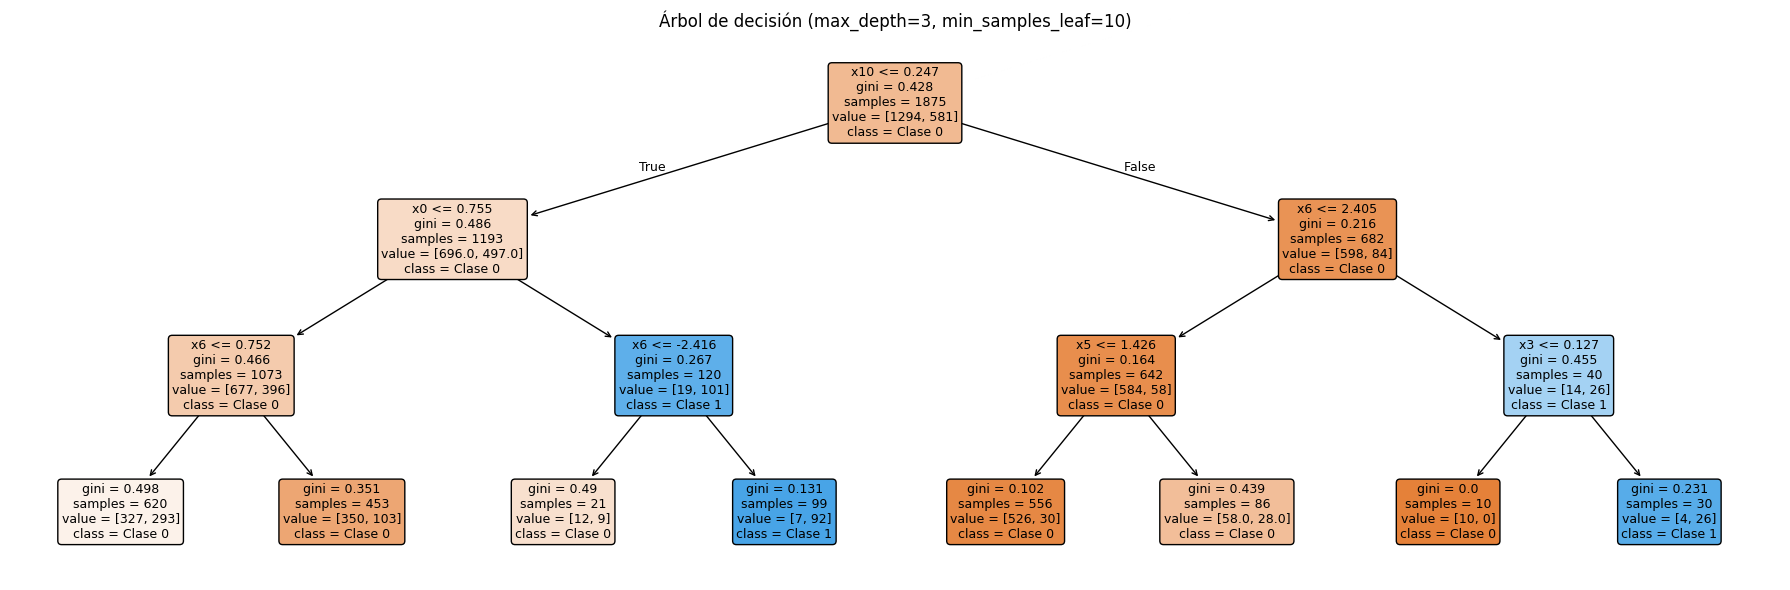

In [11]:
# 4.1 Entrenar un árbol de profundidad 3 solo para visualizar
dt_viz = DecisionTreeClassifier(max_depth=3, min_samples_leaf=10, random_state=RANDOM_STATE)
dt_viz.fit(X_train, y_train)

feature_names = [f"x{i}" for i in range(X_train.shape[1])]

fig, ax = plt.subplots(figsize=(18, 6))
plot_tree(
    dt_viz,
    feature_names=feature_names,
    class_names=["Clase 0", "Clase 1"],
    filled=True,
    rounded=True,
    ax=ax,
    fontsize=9
)
ax.set_title("Árbol de decisión (max_depth=3, min_samples_leaf=10)")
plt.tight_layout()
plt.show()

---
## 5) Feature importance (basada en impureza — MDI)

Cada feature recibe un score de importancia que mide **cuánto redujo la impureza** en promedio,  
ponderado por la proporción de muestras que pasaron por ese nodo:

$$
\text{importance}(f) = \sum_{t: \text{split en } f} \frac{n_t}{n} \cdot \Delta \text{impureza}(t)
$$

Las importancias se normalizan para que sumen 1.

> **Cuidado**: MDI sobreestima features de alta cardinalidad o con muchos valores únicos.  
> Para un análisis más robusto se usa *permutation importance* (Semana 9).

In [12]:
# 5.1 Feature importance del árbol con mejor configuración
importances = dt_best.feature_importances_
feat_names  = [f"x{i}" for i in range(len(importances))]

df_imp = pd.DataFrame({"feature": feat_names, "importance": importances})\
           .sort_values("importance", ascending=False)

print("Top features:")
print(df_imp.head(8).to_string(index=False))

Top features:
feature  importance
    x10    0.257590
     x6    0.219766
     x0    0.166204
     x3    0.158711
     x5    0.134830
     x4    0.038724
     x7    0.024175
     x1    0.000000


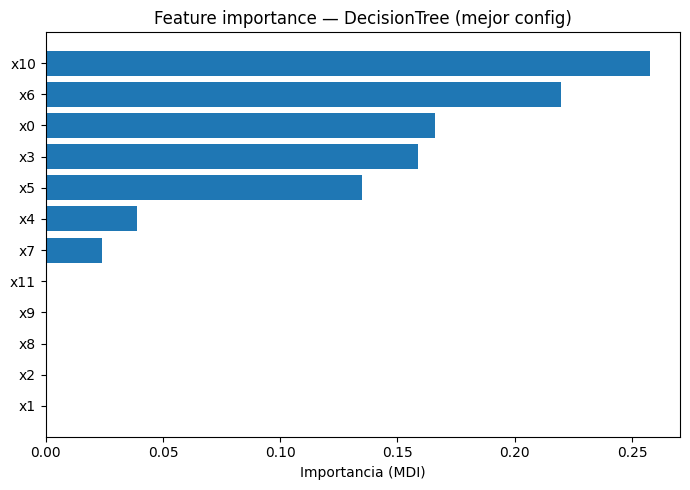

In [13]:
# 5.2 Visualizar
df_imp_plot = df_imp.sort_values("importance", ascending=True)  # ascendente para barh

plt.figure(figsize=(7, 5))
plt.barh(df_imp_plot["feature"], df_imp_plot["importance"])
plt.xlabel("Importancia (MDI)")
plt.title("Feature importance — DecisionTree (mejor config)")
plt.tight_layout()
plt.show()

In [14]:
# 5.3 Confirmar con make_classification: features informativas conocidas (x0..x5)
# El dataset tiene 6 features informativas (indices 0-5) y 3 redundantes (6-8)
# y 3 de ruido (9-11). ¿Coincide el ranking?
informative_idx = list(range(6))
print("Features informativas esperadas (x0–x5):")
print(df_imp[df_imp["feature"].isin([f"x{i}" for i in informative_idx])].to_string(index=False))

Features informativas esperadas (x0–x5):
feature  importance
     x0    0.166204
     x3    0.158711
     x5    0.134830
     x4    0.038724
     x1    0.000000
     x2    0.000000


---
## 6) Árbol de regresión (`DecisionTreeRegressor`)

Para regresión, el árbol predice el **promedio del target** en cada hoja.  
El criterio de split es el **MSE** (o MAE):

$$
\text{MSE}(t) = \frac{1}{n_t} \sum_{i \in t} (y_i - \bar{y}_t)^2
$$

Sin restricciones → el árbol puede interpolar perfectamente el train con MSE = 0.  
Con control de profundidad → predice promedios más suaves y generaliza mejor.

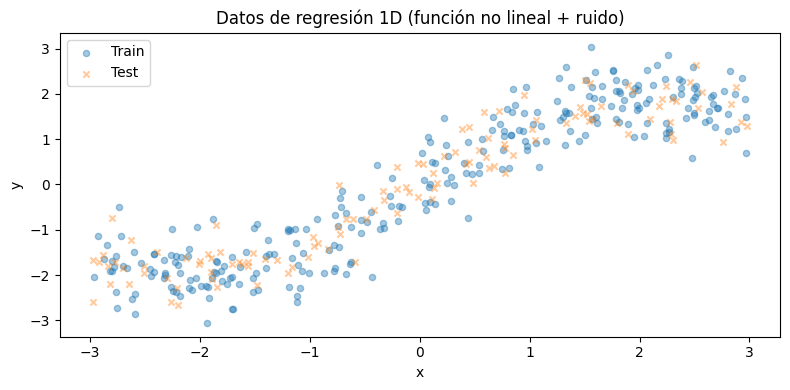

In [15]:
# 6.1 Función no lineal 1D para visualizar regresión
n_reg = 400
X_reg = rng.uniform(-3, 3, size=(n_reg, 1))
noise = rng.normal(0, 0.5, size=n_reg)
y_reg = np.sin(X_reg[:, 0]) + 0.5 * X_reg[:, 0] + noise

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.30, random_state=RANDOM_STATE
)

x_plot = np.linspace(-3, 3, 500).reshape(-1, 1)

plt.figure(figsize=(8, 4))
plt.scatter(X_reg_train, y_reg_train, alpha=0.4, s=20, label="Train")
plt.scatter(X_reg_test,  y_reg_test,  alpha=0.4, s=20, marker="x", label="Test")
plt.title("Datos de regresión 1D (función no lineal + ruido)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

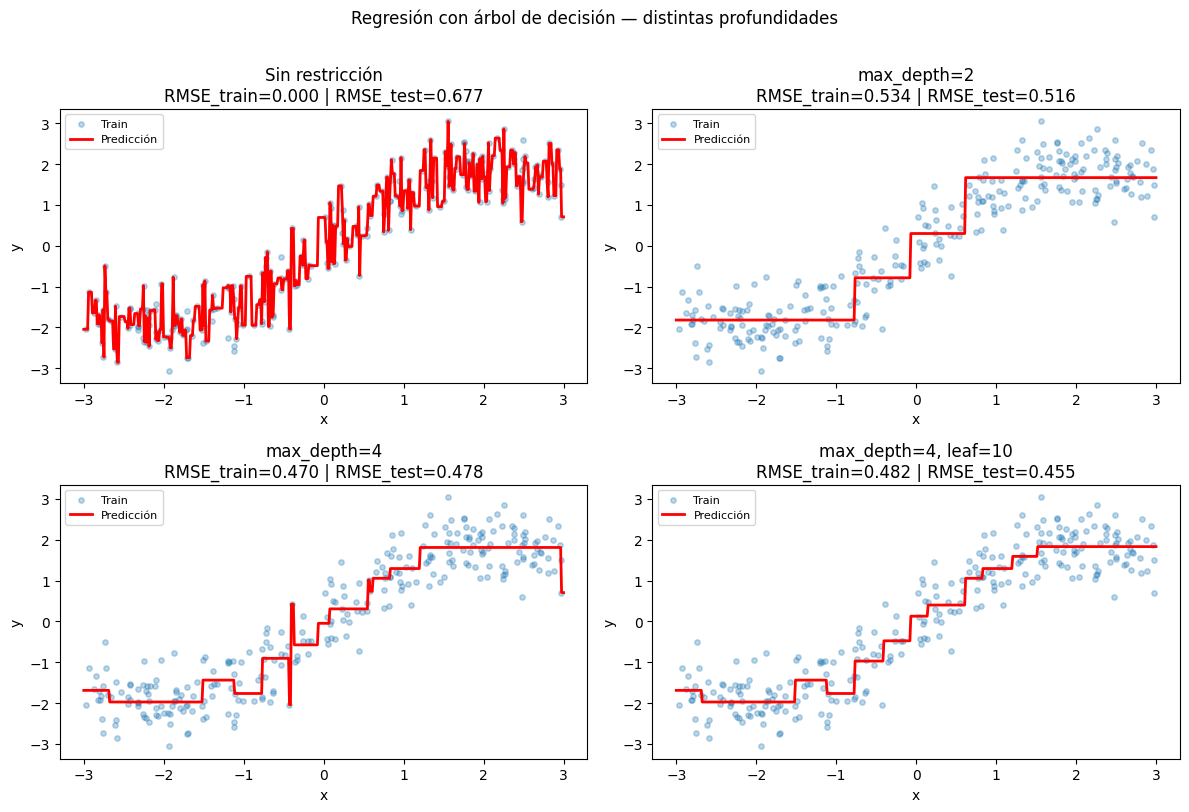

,RMSE_train,RMSE_test,R2_test
Config,,,
Sin restricción,0.000000,0.677014,0.796518
max_depth=2,0.533880,0.516445,0.881593
max_depth=4,0.469728,0.478011,0.898561
"max_depth=4, leaf=10",0.482325,0.454954,0.908111


In [16]:
# 6.2 Comparar profundidades: sin restricción vs controlado
configs = [
    ("Sin restricción",  DecisionTreeRegressor(random_state=RANDOM_STATE)),
    ("max_depth=2",      DecisionTreeRegressor(max_depth=2, random_state=RANDOM_STATE)),
    ("max_depth=4",      DecisionTreeRegressor(max_depth=4, random_state=RANDOM_STATE)),
    ("max_depth=4, leaf=10", DecisionTreeRegressor(max_depth=4, min_samples_leaf=10, random_state=RANDOM_STATE)),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

reg_results = []

for ax, (name, reg) in zip(axes, configs):
    reg.fit(X_reg_train, y_reg_train)
    y_pred_plot  = reg.predict(x_plot)
    y_pred_test  = reg.predict(X_reg_test)
    y_pred_train = reg.predict(X_reg_train)

    rmse_train = np.sqrt(mean_squared_error(y_reg_train, y_pred_train))
    rmse_test  = np.sqrt(mean_squared_error(y_reg_test,  y_pred_test))
    r2_test    = r2_score(y_reg_test, y_pred_test)

    reg_results.append({"Config": name, "RMSE_train": rmse_train, "RMSE_test": rmse_test, "R2_test": r2_test})

    ax.scatter(X_reg_train, y_reg_train, alpha=0.3, s=15, label="Train")
    ax.plot(x_plot, y_pred_plot, color="red", linewidth=2, label="Predicción")
    ax.set_title(f"{name}\nRMSE_train={rmse_train:.3f} | RMSE_test={rmse_test:.3f}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend(fontsize=8)

plt.suptitle("Regresión con árbol de decisión — distintas profundidades", y=1.01)
plt.tight_layout()
plt.show()

pd.DataFrame(reg_results).set_index("Config")

---
## 7) Comparación final: Árbol vs Logística vs Baseline (clasificación tabular)

Usamos el **dataset tabular** de la sección 3 para comparar los tres modelos con el mismo split train/test.  
Nota: los árboles **no necesitan escalado** (los cortes son relativos → invariantes a escala).

In [17]:
# 7.1 Entrenar los tres modelos
# --- Árbol (mejor config de CV)
dt_final = DecisionTreeClassifier(
    max_depth=best_depth, min_samples_leaf=best_leaf,
    random_state=RANDOM_STATE
)
dt_final.fit(X_train, y_train)

# --- Árbol sin restricciones (referencia de sobreajuste)
dt_overfit = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_overfit.fit(X_train, y_train)

# --- Regresión logística (escalado necesario)
lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=3000))
])
lr_pipe.fit(X_train, y_train)

# --- Baseline
dummy.fit(X_train, y_train)

# 7.2 Métricas
models = {
    "Dummy": dummy,
    "DT sin restricción": dt_overfit,
    f"DT (d={best_depth}, leaf={best_leaf})": dt_final,
    "LogReg": lr_pipe,
}

results = []
for name, model in models.items():
    pred  = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    row   = clf_metrics(y_test, pred, proba)
    row["Model"] = name
    # Train accuracy para detectar sobreajuste
    row["Acc_train"] = accuracy_score(y_train, model.predict(X_train))
    results.append(row)

df_final = pd.DataFrame(results).set_index("Model")
df_final[["Acc_train", "Accuracy", "BalancedAcc", "F1", "ROC_AUC", "PR_AUC"]]

,Acc_train,Accuracy,BalancedAcc,F1,ROC_AUC,PR_AUC
Model,,,,,,
Dummy,0.690133,0.6896,0.500000,0.000000,0.500000,0.310400
DT sin restricción,1.000000,0.7808,0.744696,0.647815,0.744696,0.528467
"DT (d=4, leaf=1)",0.788267,0.7264,0.708087,0.599532,0.753008,0.532506
LogReg,0.742933,0.7008,0.566227,0.304833,0.645705,0.508155


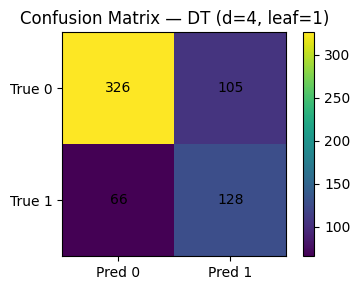

In [18]:
# 7.3 Matriz de confusión — DT con mejor config (test)
pred_dt = dt_final.predict(X_test)
cm_dt   = confusion_matrix(y_test, pred_dt)

plt.figure(figsize=(4, 3))
plt.imshow(cm_dt, interpolation="nearest")
plt.title(f"Confusion Matrix — DT (d={best_depth}, leaf={best_leaf})")
plt.colorbar()
plt.xticks([0, 1], ["Pred 0", "Pred 1"])
plt.yticks([0, 1], ["True 0", "True 1"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_dt[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()

---
## 8) Ejercicios (Semana 7)

### Ejercicio 1 — `max_depth`
1. Reproduce la curva de la sección 2 pero usando **F1** en lugar de accuracy.
2. ¿Cambia el `max_depth` óptimo? ¿Por qué podría diferir del óptimo en accuracy?

### Ejercicio 2 — `min_samples_leaf`
1. Fija `max_depth=5` y varía `min_samples_leaf` en `[1, 2, 5, 10, 20, 50, 100]`.
2. Grafica F1 (train y test) en función de `min_samples_leaf` y comenta la curva de sesgo-varianza.

### Ejercicio 3 — Comparar configuraciones
1. Completa la tabla de la sección 7 añadiendo un cuarto árbol con `max_depth=1` (stumped tree).
2. ¿En qué métrica la logística supera claramente al árbol? ¿Por qué crees que ocurre eso?

### Ejercicio 4 — Feature importance
1. Entrena un árbol sin restricciones y uno controlado (tu mejor config) y compara sus feature importances.
2. ¿Cambia el ranking de features entre ambos árboles? Explica qué podría causar diferencias.

### Ejercicio 5 — Regresión (conceptual + código)
1. En la sección 6, ¿qué RMSE de test corresponde a un árbol con `max_depth=1`? ¿Y con `max_depth=10`?
2. Explica con tus palabras por qué un árbol de regresión **no puede extrapolar** fuera del rango de entrenamiento.